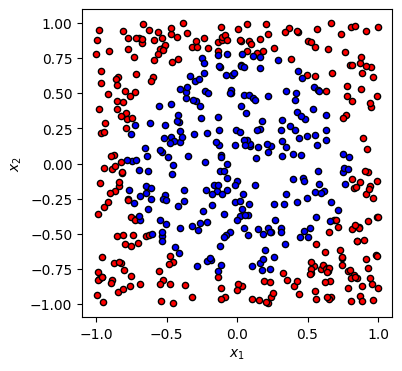

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer, GradientDescentOptimizer

import matplotlib.pyplot as plt


# Set a random seed
np.random.seed(13202050)


# Make a dataset of points inside and outside of a circle
def circle(samples, center=[0.0, 0.0], radius=np.sqrt(2 / np.pi)):
    """
    Generates a dataset of points with 1/0 labels inside a given radius.

    Args:
        samples (int): number of samples to generate
        center (tuple): center of the circle
        radius (float: radius of the circle

    Returns:
        Xvals (array[tuple]): coordinates of points
        yvals (array[int]): classification labels
    """
    Xvals, yvals = [], []

    for i in range(samples):
        x = 2 * (np.random.rand(2)) - 1
        y = 0
        if np.linalg.norm(x - center) < radius:
            y = 1
        Xvals.append(x)
        yvals.append(y)
    return np.array(Xvals, requires_grad=False), np.array(yvals, requires_grad=False)


def plot_data(x, y, fig=None, ax=None):
    """
    Plot data with red/blue values for a binary classification.

    Args:
        x (array[tuple]): array of data points as tuples
        y (array[int]): array of data points as tuples
    """
    if fig == None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    reds = y == 0
    blues = y == 1
    ax.scatter(x[reds, 0], x[reds, 1], c="red", s=20, edgecolor="k")
    ax.scatter(x[blues, 0], x[blues, 1], c="blue", s=20, edgecolor="k")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")


Xdata, ydata = circle(500)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_data(Xdata, ydata, fig=fig, ax=ax)
plt.show()


# Define output labels as quantum state vectors
def density_matrix(state):
    """Calculates the density matrix representation of a state.

    Args:
        state (array[complex]): array representing a quantum state vector

    Returns:
        dm: (array[complex]): array representing the density matrix
    """
    return state * np.conj(state).T


label_0 = [[1], [0]]
label_1 = [[0], [1]]
state_labels = np.array([label_0, label_1], requires_grad=False)

In [3]:
dev = qml.device("lightning.qubit", wires=1)
# Install any pennylane-plugin to run on some particular backend


@qml.qnode(dev)
def qcircuit(params, x, y):
    """A variational quantum circuit representing the Universal classifier.

    Args:
        params (array[float]): array of parameters
        x (array[float]): single input vector
        y (array[float]): single output state density matrix

    Returns:
        float: fidelity between output state and input
    """
    for p in params:
        qml.Rot(*x, wires=0)
        qml.Rot(*p, wires=0)
    return qml.expval(qml.Hermitian(y, wires=[0]))


def cost(params, x, y, state_labels=None):
    """Cost function to be minimized.

    Args:
        params (array[float]): array of parameters
        x (array[float]): 2-d array of input vectors
        y (array[float]): 1-d array of targets
        state_labels (array[float]): array of state representations for labels

    Returns:
        float: loss value to be minimized
    """
    # Compute prediction for each input in data batch
    loss = 0.0
    dm_labels = [density_matrix(s) for s in state_labels]
    for i in range(len(x)):
        f = qcircuit(params, x[i], dm_labels[y[i]])
        loss = loss + (1 - f) ** 2
    return loss / len(x)

In [4]:
def test(params, x, y, state_labels=None):
    """
    Tests on a given set of data.

    Args:
        params (array[float]): array of parameters
        x (array[float]): 2-d array of input vectors
        y (array[float]): 1-d array of targets
        state_labels (array[float]): 1-d array of state representations for labels

    Returns:
        predicted (array([int]): predicted labels for test data
        output_states (array[float]): output quantum states from the circuit
    """
    fidelity_values = []
    dm_labels = [density_matrix(s) for s in state_labels]
    predicted = []

    for i in range(len(x)):
        fidel_function = lambda y: qcircuit(params, x[i], y)
        fidelities = [fidel_function(dm) for dm in dm_labels]
        best_fidel = np.argmax(fidelities)

        predicted.append(best_fidel)
        fidelity_values.append(fidelities)

    return np.array(predicted), np.array(fidelity_values)


def accuracy_score(y_true, y_pred):
    """Accuracy score.

    Args:
        y_true (array[float]): 1-d array of targets
        y_predicted (array[float]): 1-d array of predictions
        state_labels (array[float]): 1-d array of state representations for labels

    Returns:
        score (float): the fraction of correctly classified samples
    """
    score = y_true == y_pred
    return score.sum() / len(y_true)


def iterate_minibatches(inputs, targets, batch_size):
    """
    A generator for batches of the input data

    Args:
        inputs (array[float]): input data
        targets (array[float]): targets

    Returns:
        inputs (array[float]): one batch of input data of length `batch_size`
        targets (array[float]): one batch of targets of length `batch_size`
    """
    for start_idx in range(0, inputs.shape[0] - batch_size + 1, batch_size):
        idxs = slice(start_idx, start_idx + batch_size)
        yield inputs[idxs], targets[idxs]

In [5]:
# Generate training and test data
num_training = 200
num_test = 2000

Xdata, y_train = circle(num_training)
X_train = np.hstack((Xdata, np.zeros((Xdata.shape[0], 1), requires_grad=False)))

Xtest, y_test = circle(num_test)
X_test = np.hstack((Xtest, np.zeros((Xtest.shape[0], 1), requires_grad=False)))


# Train using Adam optimizer and evaluate the classifier
num_layers = 3
learning_rate = 0.6
epochs = 10
batch_size = 32

opt = AdamOptimizer(learning_rate, beta1=0.9, beta2=0.999)

# initialize random weights
params = np.random.uniform(size=(num_layers, 3), requires_grad=True)

predicted_train, fidel_train = test(params, X_train, y_train, state_labels)
accuracy_train = accuracy_score(y_train, predicted_train)

predicted_test, fidel_test = test(params, X_test, y_test, state_labels)
accuracy_test = accuracy_score(y_test, predicted_test)

# save predictions with random weights for comparison
initial_predictions = predicted_test

loss = cost(params, X_test, y_test, state_labels)

print(
    "Epoch: {:2d} | Cost: {:3f} | Train accuracy: {:3f} | Test Accuracy: {:3f}".format(
        0, loss, accuracy_train, accuracy_test
    )
)

for it in range(epochs):
    for Xbatch, ybatch in iterate_minibatches(X_train, y_train, batch_size=batch_size):
        params, _, _, _ = opt.step(cost, params, Xbatch, ybatch, state_labels)

    predicted_train, fidel_train = test(params, X_train, y_train, state_labels)
    accuracy_train = accuracy_score(y_train, predicted_train)
    loss = cost(params, X_train, y_train, state_labels)

    predicted_test, fidel_test = test(params, X_test, y_test, state_labels)
    accuracy_test = accuracy_score(y_test, predicted_test)
    res = [it + 1, loss, accuracy_train, accuracy_test]
    print(
        "Epoch: {:2d} | Loss: {:3f} | Train accuracy: {:3f} | Test accuracy: {:3f}".format(
            *res
        )
    )

Epoch:  0 | Cost: 0.312247 | Train accuracy: 0.595000 | Test Accuracy: 0.577000
Epoch:  1 | Loss: 0.110766 | Train accuracy: 0.855000 | Test accuracy: 0.799500
Epoch:  2 | Loss: 0.113112 | Train accuracy: 0.850000 | Test accuracy: 0.788500
Epoch:  3 | Loss: 0.118929 | Train accuracy: 0.835000 | Test accuracy: 0.781500
Epoch:  4 | Loss: 0.113877 | Train accuracy: 0.845000 | Test accuracy: 0.795500
Epoch:  5 | Loss: 0.107504 | Train accuracy: 0.910000 | Test accuracy: 0.846000
Epoch:  6 | Loss: 0.103763 | Train accuracy: 0.915000 | Test accuracy: 0.862500
Epoch:  7 | Loss: 0.099117 | Train accuracy: 0.905000 | Test accuracy: 0.860000
Epoch:  8 | Loss: 0.099569 | Train accuracy: 0.885000 | Test accuracy: 0.845500
Epoch:  9 | Loss: 0.101582 | Train accuracy: 0.895000 | Test accuracy: 0.840500
Epoch: 10 | Loss: 0.105573 | Train accuracy: 0.900000 | Test accuracy: 0.868000


Cost: 0.105573 | Train accuracy 0.900000 | Test Accuracy : 0.868000
Learned weights
Layer 0: [-0.05298154  1.59643106 -0.25728026]
Layer 1: [0.34058154 0.23505932 1.06746152]
Layer 2: [-1.01953566  1.66714406  0.3163603 ]


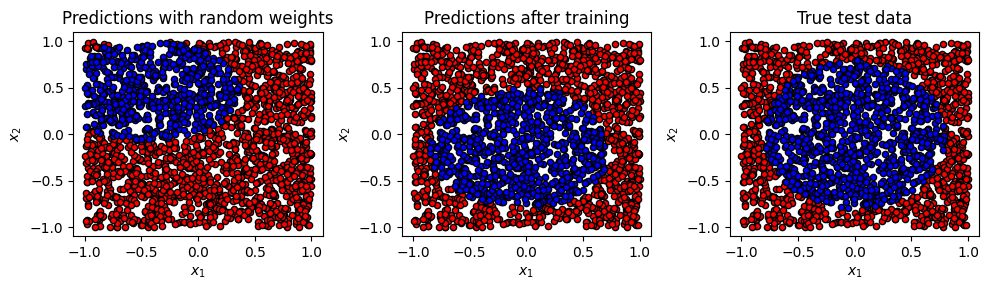

In [6]:
print(
    "Cost: {:3f} | Train accuracy {:3f} | Test Accuracy : {:3f}".format(
        loss, accuracy_train, accuracy_test
    )
)

print("Learned weights")
for i in range(num_layers):
    print("Layer {}: {}".format(i, params[i]))


fig, axes = plt.subplots(1, 3, figsize=(10, 3))
plot_data(X_test, initial_predictions, fig, axes[0])
plot_data(X_test, predicted_test, fig, axes[1])
plot_data(X_test, y_test, fig, axes[2])
axes[0].set_title("Predictions with random weights")
axes[1].set_title("Predictions after training")
axes[2].set_title("True test data")
plt.tight_layout()
plt.show()

***
**2.1  the performance on the circle dataset**

Running n = 2


/Users/daniellin/miniconda3/envs/qce/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Running n = 3


/Users/daniellin/miniconda3/envs/qce/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Running n = 4
Running n = 5


/Users/daniellin/miniconda3/envs/qce/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Running n = 6
Running n = 7
Running n = 8
Running n = 9
Running n = 10
Running n = 11
Running n = 12


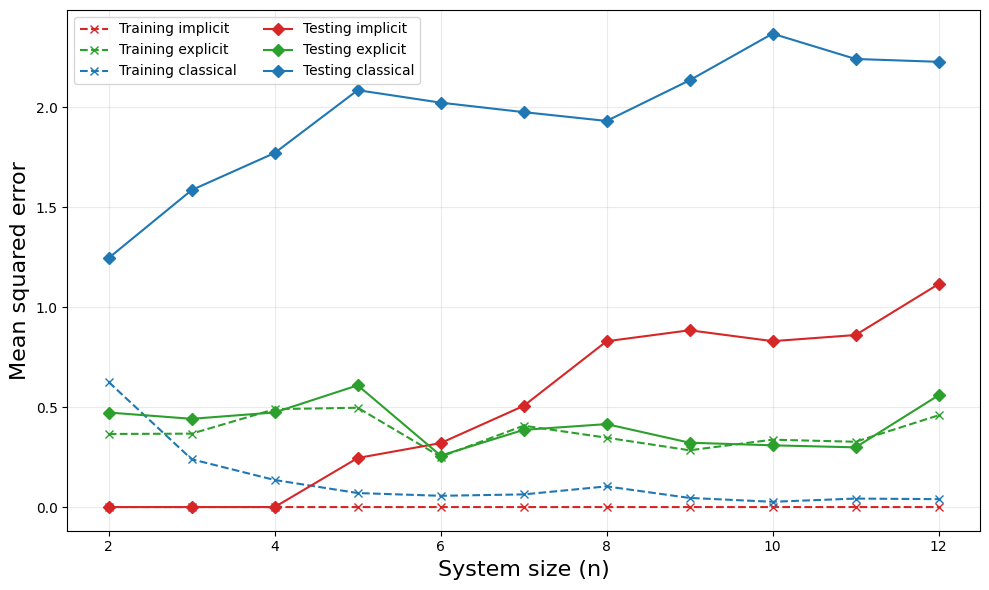

In [30]:
import pennylane as qml
import numpy as onp
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer

import matplotlib.pyplot as plt
import time

from sklearn.decomposition import PCA
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
SEED = 13202050

#################

def load_fashion_mnist_pca(n_components, train_size=1000, test_size=100, seed=1320202050):
    X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)

    X = X.astype("float32") / 255.0

    rng = onp.random.RandomState(seed)
    idx = rng.choice(len(X), size=train_size + test_size, replace=False)
    X = X[idx]

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=seed)
    X_pca = pca.fit_transform(X)

    X_train = X_pca[:train_size]
    X_test = X_pca[train_size:train_size + test_size]

    return np.array(X_train, requires_grad=False), np.array(X_test, requires_grad=False)


def feature_map(x, wires):
    n = len(wires)

    for i in range(n):
        qml.Hadamard(wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

    for i in range(n - 1):
        qml.IsingZZ(x[i] * x[i + 1], wires=[wires[i], wires[i + 1]])

def hardware_efficient_ansatz(params, wires):
    n_layers = params.shape[0]
    n_qubits = len(wires)

    for l in range(n_layers):
        for q in range(n_qubits):
            qml.Rot(params[l, q, 0], params[l, q, 1], params[l, q, 2], wires=wires[q])

        for q in range(n_qubits - 1):
            qml.CNOT(wires=[wires[q], wires[q + 1]])
class ExplicitQuantumRegressor:
    def __init__(self, n_qubits, n_layers=2, steps=50, lr=0.05):
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.steps = steps
        self.lr = lr
        self.dev = qml.device("default.qubit", wires=n_qubits)
        self.params = 0.01 * np.random.randn(n_layers, n_qubits, 3, requires_grad=True)
        self.training_time = None

        @qml.qnode(self.dev, interface="autograd")
        def circuit(x, params):
            wires = list(range(self.n_qubits))
            feature_map(x, wires)
            hardware_efficient_ansatz(params, wires)
            return qml.expval(qml.PauliZ(0))

        self.circuit = circuit

    def predict_scores(self, X):
        return np.array([self.circuit(x, self.params) for x in X], requires_grad=False)

    def loss(self, params, X, y):
        preds = np.array([self.circuit(x, params) for x in X])
        return np.mean((preds - y) ** 2)

    def fit(self, X, y):
        opt = AdamOptimizer(self.lr)
        params = self.params
        start = time.perf_counter()

        for step in range(self.steps):
            params = opt.step(lambda v: self.loss(v, X, y), params)

        self.params = params
        self.training_time = time.perf_counter() - start

    def num_params(self):
        return self.n_layers * self.n_qubits * 3

def generate_teacher_labels(X_train, X_test, n_qubits, seed=1320202050):
    np.random.seed(seed)
    teacher = ExplicitQuantumRegressor(n_qubits=n_qubits, n_layers=2, steps=0, lr=0.05)

    y_train = teacher.predict_scores(X_train)
    y_test = teacher.predict_scores(X_test)

    # optional: normalize to std = 1, matching paper note
    std = onp.std(onp.array(y_train))
    if std > 1e-8:
        y_train = y_train / std
        y_test = y_test / std

    return y_train, y_test
class ImplicitQuantumKernelRegressor:
    def __init__(self, n_qubits, alpha=1e-3):
        self.n_qubits = n_qubits
        self.alpha = alpha
        self.X_train = None
        self.training_time = None
        self.model = KernelRidge(alpha=alpha, kernel="precomputed")
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            wires = list(range(self.n_qubits))
            feature_map(x1, wires)
            qml.adjoint(feature_map)(x2, wires=wires)
            return qml.probs(wires=wires)

        self.kernel_circuit = kernel_circuit

    def kernel(self, x1, x2):
        return self.kernel_circuit(x1, x2)[0]

    def compute_kernel_matrix(self, X1, X2):
        K = onp.zeros((len(X1), len(X2)))
        for i in range(len(X1)):
            for j in range(len(X2)):
                K[i, j] = self.kernel(X1[i], X2[j])
        return K

    def fit(self, X, y):
        self.X_train = X
        start = time.perf_counter()
        K_train = self.compute_kernel_matrix(X, X)
        self.model.fit(K_train, onp.array(y))
        self.training_time = time.perf_counter() - start

    def predict_scores(self, X):
        K_test = self.compute_kernel_matrix(X, self.X_train)
        return self.model.predict(K_test)

class ClassicalRegressor:
    def __init__(self):
        self.model = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=1320202050)
        self.training_time = None

    def fit(self, X, y):
        start = time.perf_counter()
        self.model.fit(onp.array(X), onp.array(y))
        self.training_time = time.perf_counter() - start

    def predict_scores(self, X):
        return self.model.predict(onp.array(X))
        
def run_fig6_paper_style(system_sizes=range(2, 11), train_size = 100, test_size = 100):
    train_imp, test_imp = [], []
    train_exp, test_exp = [], []
    train_cls, test_cls = [], []

    for n in system_sizes:
        print(f"Running n = {n}")

        X_train, X_test = load_fashion_mnist_pca(
            n_components=n, train_size=train_size, test_size=test_size, seed=1320202050
        )

        y_train, y_test = generate_teacher_labels(X_train, X_test, n_qubits=n, seed=1320202050)

        # explicit
        exp_model = ExplicitQuantumRegressor(n_qubits=n, n_layers=2, steps=50, lr=0.05)
        exp_model.fit(X_train, y_train)
        yhat_train_exp = exp_model.predict_scores(X_train)
        yhat_test_exp = exp_model.predict_scores(X_test)

        # implicit
        imp_model = ImplicitQuantumKernelRegressor(n_qubits=n, alpha=1e-3)
        imp_model.fit(X_train, y_train)
        yhat_train_imp = imp_model.predict_scores(X_train)
        yhat_test_imp = imp_model.predict_scores(X_test)

        # classical
        cls_model = ClassicalRegressor()
        cls_model.fit(X_train, y_train)
        yhat_train_cls = cls_model.predict_scores(X_train)
        yhat_test_cls = cls_model.predict_scores(X_test)

        train_imp.append(mean_squared_error(onp.array(y_train), onp.array(yhat_train_imp)))
        test_imp.append(mean_squared_error(onp.array(y_test), onp.array(yhat_test_imp)))

        train_exp.append(mean_squared_error(onp.array(y_train), onp.array(yhat_train_exp)))
        test_exp.append(mean_squared_error(onp.array(y_test), onp.array(yhat_test_exp)))

        train_cls.append(mean_squared_error(onp.array(y_train), onp.array(yhat_train_cls)))
        test_cls.append(mean_squared_error(onp.array(y_test), onp.array(yhat_test_cls)))

    plt.figure(figsize=(10, 6))

    plt.plot(system_sizes, train_imp, '--', marker='x', color='tab:red', label='Training implicit')
    plt.plot(system_sizes, train_exp, '--', marker='x', color='tab:green', label='Training explicit')
    plt.plot(system_sizes, train_cls, '--', marker='x', color='tab:blue', label='Training classical')

    plt.plot(system_sizes, test_imp, '-', marker='D', color='tab:red', label='Testing implicit')
    plt.plot(system_sizes, test_exp, '-', marker='D', color='tab:green', label='Testing explicit')
    plt.plot(system_sizes, test_cls, '-', marker='D', color='tab:blue', label='Testing classical')

    plt.xlabel("System size (n)", fontsize=16)
    plt.ylabel("Mean squared error", fontsize=16)
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return {
        "n": list(system_sizes),
        "train_imp": train_imp, "test_imp": test_imp,
        "train_exp": train_exp, "test_exp": test_exp,
        "train_cls": train_cls, "test_cls": test_cls,
    }
results = run_fig6_paper_style(system_sizes=range(2, 13), train_size=200, test_size=200)

**2.2 the decision boundarie and  comparison table**

               Model  Train Accuracy  Test Accuracy  Params  Kernel Evals  \
0  Reupload (Circle)          0.9214         0.8500     9.0           NaN   
1  Explicit (Circle)          0.5000         0.5333     9.0           NaN   
2    Kernel (Circle)          0.7357         0.7500     NaN       19600.0   
3   Reupload (Moons)          0.9571         0.9000     9.0           NaN   
4   Explicit (Moons)          0.8214         0.7833     9.0           NaN   
5     Kernel (Moons)          0.8286         0.7833     NaN       19600.0   

   Training Time (s)  
0            52.7249  
1            46.9165  
2            11.5013  
3            52.5687  
4            46.8371  
5            11.3515  


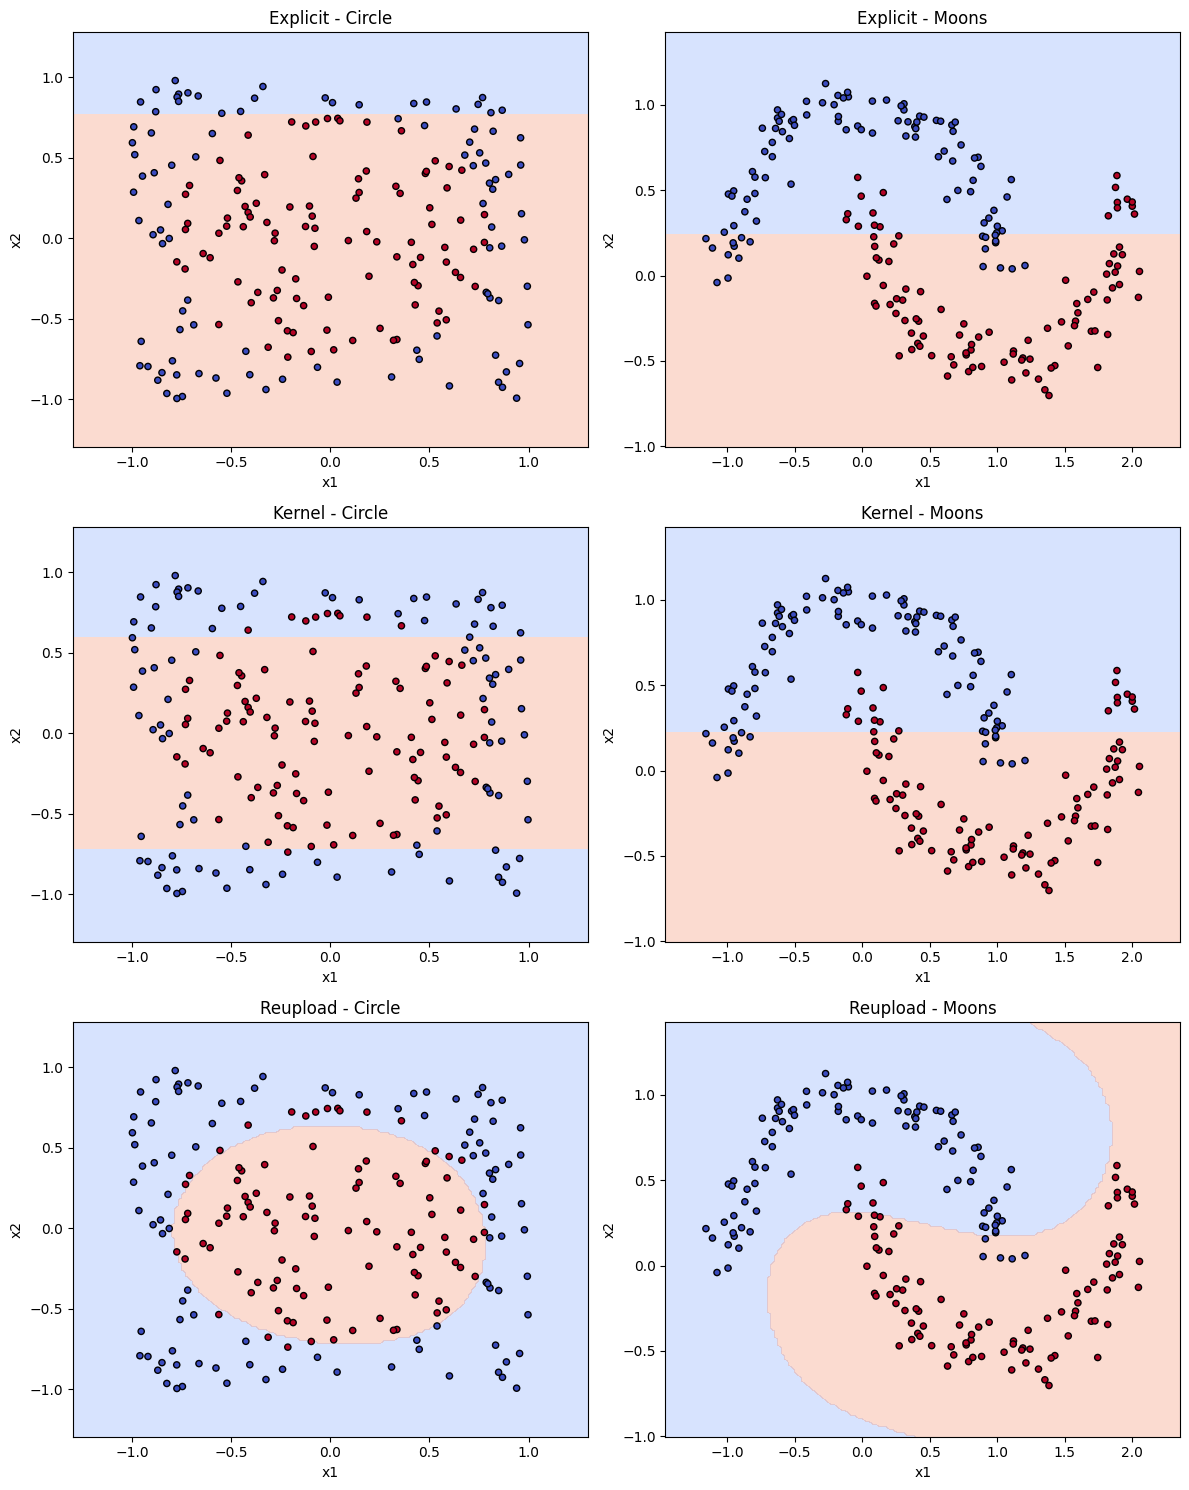

In [29]:
import pennylane as qml
import numpy as onp
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer

import matplotlib.pyplot as plt
import time
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# =========================================================
# 0. Global seed
# =========================================================
SEED = 13202050
np.random.seed(SEED)
onp.random.seed(SEED)


# =========================================================
# 1. Dataset
# =========================================================
def circle(samples, center=[0.0, 0.0], radius=np.sqrt(2 / np.pi)):
    Xvals, yvals = [], []

    for _ in range(samples):
        x = 2 * np.random.rand(2) - 1
        y = 1 if np.linalg.norm(x - center) < radius else 0
        Xvals.append(x)
        yvals.append(y)

    return np.array(Xvals, requires_grad=False), np.array(yvals, requires_grad=False)


def moons(samples=200, noise=0.1, seed=SEED):
    X, y = make_moons(n_samples=samples, noise=noise, random_state=seed)
    return np.array(X, requires_grad=False), np.array(y, requires_grad=False)


def to_pm_one(y):
    return np.array(2 * y - 1, requires_grad=False)


# =========================================================
# 2. Data re-uploading model
# =========================================================
dev_reupload = qml.device("default.qubit", wires=1)


@qml.qnode(dev_reupload, interface="autograd")
def reupload_circuit(x, params):
    for p in params:
        qml.Rot(x[0], x[1], 0.0, wires=0)
        qml.Rot(p[0], p[1], p[2], wires=0)
    return qml.expval(qml.PauliZ(0))


class DataReuploadingClassifier:
    def __init__(self, n_layers=3, steps=30, lr=0.1):
        self.n_layers = n_layers
        self.steps = steps
        self.lr = lr
        self.params = 0.01 * np.random.randn(n_layers, 3, requires_grad=True)
        self.training_time = None

    def predict_scores(self, X):
        return np.array([reupload_circuit(x, self.params) for x in X], requires_grad=False)

    def predict(self, X):
        scores = self.predict_scores(X)
        return np.array((scores > 0).astype(int), requires_grad=False)

    def loss(self, params, X, y_pm):
        preds = np.array([reupload_circuit(x, params) for x in X])
        return np.mean((preds - y_pm) ** 2)

    def fit(self, X, y):
        y_pm = to_pm_one(y)
        opt = AdamOptimizer(self.lr)
        params = self.params
        start = time.perf_counter()

        for _ in range(self.steps):
            params = opt.step(lambda v: self.loss(v, X, y_pm), params)

        self.params = params
        self.training_time = time.perf_counter() - start

    def num_params(self):
        return self.n_layers * 3


# =========================================================
# 3. Explicit quantum model
# =========================================================
dev_explicit = qml.device("default.qubit", wires=1)


@qml.qnode(dev_explicit, interface="autograd")
def explicit_circuit(x, params):
    qml.Rot(x[0], x[1], 0.0, wires=0)
    for p in params:
        qml.Rot(p[0], p[1], p[2], wires=0)
    return qml.expval(qml.PauliZ(0))


class ExplicitQuantumClassifier:
    def __init__(self, n_layers=3, steps=30, lr=0.1):
        self.n_layers = n_layers
        self.steps = steps
        self.lr = lr
        self.params = 0.01 * np.random.randn(n_layers, 3, requires_grad=True)
        self.training_time = None

    def predict_scores(self, X):
        return np.array([explicit_circuit(x, self.params) for x in X], requires_grad=False)

    def predict(self, X):
        scores = self.predict_scores(X)
        return np.array((scores > 0).astype(int), requires_grad=False)

    def loss(self, params, X, y_pm):
        preds = np.array([explicit_circuit(x, params) for x in X])
        return np.mean((preds - y_pm) ** 2)

    def fit(self, X, y):
        y_pm = to_pm_one(y)
        opt = AdamOptimizer(self.lr)
        params = self.params
        start = time.perf_counter()

        for _ in range(self.steps):
            params = opt.step(lambda v: self.loss(v, X, y_pm), params)

        self.params = params
        self.training_time = time.perf_counter() - start

    def num_params(self):
        return self.n_layers * 3


# =========================================================
# 4. Implicit quantum kernel model
# =========================================================
dev_kernel = qml.device("default.qubit", wires=1)


def feature_map(x):
    qml.Rot(x[0], x[1], 0.0, wires=0)


@qml.qnode(dev_kernel)
def kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=0)


class ImplicitQuantumKernelClassifier:
    def __init__(self, C=1.0):
        self.C = C
        self.clf = SVC(kernel="precomputed", C=C)
        self.X_train = None
        self.training_time = None
        self.K_train = None

    def kernel(self, x1, x2):
        return kernel_circuit(x1, x2)[0]

    def compute_kernel_matrix(self, X1, X2):
        K = np.zeros((len(X1), len(X2)), requires_grad=False)
        for i in range(len(X1)):
            for j in range(len(X2)):
                K[i, j] = self.kernel(X1[i], X2[j])
        return K

    def fit(self, X, y):
        self.X_train = X
        start = time.perf_counter()
        self.K_train = self.compute_kernel_matrix(X, X)
        self.clf.fit(self.K_train, y)
        self.training_time = time.perf_counter() - start

    def predict(self, X):
        K_test = self.compute_kernel_matrix(X, self.X_train)
        return self.clf.predict(K_test)

    def predict_scores(self, X):
        K_test = self.compute_kernel_matrix(X, self.X_train)
        return self.clf.decision_function(K_test)

    def num_kernel_evals(self):
        if self.X_train is None:
            return 0
        return len(self.X_train) * len(self.X_train)


# =========================================================
# 5. Evaluation for (c)
# =========================================================
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="model"):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    if hasattr(model, "num_params"):
        complexity = model.num_params()
        complexity_name = "params"
    else:
        complexity = model.num_kernel_evals()
        complexity_name = "kernel_evals"

    return {
        "model": model_name,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "complexity": complexity,
        "complexity_name": complexity_name,
        "training_time": model.training_time,
    }


def run_all_models_on_dataset(X_train, y_train, X_test, y_test, dataset_name="dataset",
                              n_layers=3, steps=30, lr=0.1, C=1.0):
    results = []

    reupload_model = DataReuploadingClassifier(n_layers=n_layers, steps=steps, lr=lr)
    results.append(
        evaluate_model(reupload_model, X_train, y_train, X_test, y_test,
                       model_name=f"Reupload ({dataset_name})")
    )

    explicit_model = ExplicitQuantumClassifier(n_layers=n_layers, steps=steps, lr=lr)
    results.append(
        evaluate_model(explicit_model, X_train, y_train, X_test, y_test,
                       model_name=f"Explicit ({dataset_name})")
    )

    kernel_model = ImplicitQuantumKernelClassifier(C=C)
    results.append(
        evaluate_model(kernel_model, X_train, y_train, X_test, y_test,
                       model_name=f"Kernel ({dataset_name})")
    )

    return results


def make_comparison_table(circle_results, moons_results):
    all_results = circle_results + moons_results

    rows = []
    for r in all_results:
        rows.append({
            "Model": r["model"],
            "Train Accuracy": round(r["train_acc"], 4),
            "Test Accuracy": round(r["test_acc"], 4),
            "Params": r["complexity"] if r["complexity_name"] == "params" else None,
            "Kernel Evals": r["complexity"] if r["complexity_name"] == "kernel_evals" else None,
            "Training Time (s)": round(r["training_time"], 4),
        })

    return pd.DataFrame(rows)


# =========================================================
# 6. Decision boundaries for (b)
# =========================================================
def plot_decision_boundary(model, X, y, ax, title="Decision Boundary", grid_points=150):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if hasattr(model, "predict_scores"):
        scores = model.predict_scores(grid)
        Z = np.array(scores > 0, dtype=int)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, levels=np.arange(-0.5, 2, 1), cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=20)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


def plot_3x2_decision_boundaries(
    reupload_circle, explicit_circle, kernel_circle,
    reupload_moons, explicit_moons, kernel_moons,
    X_circle, y_circle, X_moons, y_moons
):
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))

    plot_decision_boundary(explicit_circle, X_circle, y_circle, axes[0, 0], "Explicit - Circle")
    plot_decision_boundary(explicit_moons, X_moons, y_moons, axes[0, 1], "Explicit - Moons")

    plot_decision_boundary(kernel_circle, X_circle, y_circle, axes[1, 0], "Kernel - Circle")
    plot_decision_boundary(kernel_moons, X_moons, y_moons, axes[1, 1], "Kernel - Moons")

    plot_decision_boundary(reupload_circle, X_circle, y_circle, axes[2, 0], "Reupload - Circle")
    plot_decision_boundary(reupload_moons, X_moons, y_moons, axes[2, 1], "Reupload - Moons")

    plt.tight_layout()
    plt.show()


# =========================================================
# 8. Run (b)(c)
# =========================================================
X_circle, y_circle = circle(200)
X_moons, y_moons = moons(200, noise=0.1, seed=SEED)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_circle, y_circle, test_size=0.3, random_state=SEED, stratify=y_circle
)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=SEED, stratify=y_moons
)

# (c) comparison table
circle_results = run_all_models_on_dataset(
    Xc_train, yc_train, Xc_test, yc_test,
    dataset_name="Circle", n_layers=3, steps=100, lr=0.1, C=1.0
)

moons_results = run_all_models_on_dataset(
    Xm_train, ym_train, Xm_test, ym_test,
    dataset_name="Moons", n_layers=3, steps=100, lr=0.1, C=1.0
)

df_results = make_comparison_table(circle_results, moons_results)
print(df_results)

# (b) decision boundaries
reupload_circle = DataReuploadingClassifier(n_layers=3, steps=100, lr=0.1)
reupload_circle.fit(Xc_train, yc_train)

explicit_circle = ExplicitQuantumClassifier(n_layers=3, steps=100, lr=0.1)
explicit_circle.fit(Xc_train, yc_train)

kernel_circle = ImplicitQuantumKernelClassifier(C=1.0)
kernel_circle.fit(Xc_train, yc_train)

reupload_moons = DataReuploadingClassifier(n_layers=3, steps=100, lr=0.1)
reupload_moons.fit(Xm_train, ym_train)

explicit_moons = ExplicitQuantumClassifier(n_layers=3, steps=100, lr=0.1)
explicit_moons.fit(Xm_train, ym_train)

kernel_moons = ImplicitQuantumKernelClassifier(C=1.0)
kernel_moons.fit(Xm_train, ym_train)

plot_3x2_decision_boundaries(
    reupload_circle, explicit_circle, kernel_circle,
    reupload_moons, explicit_moons, kernel_moons,
    X_circle, y_circle, X_moons, y_moons
)